<a href="https://colab.research.google.com/github/devdatacode55/AI-Based-Agricultural-Input-Cost-Forecasting/blob/main/Agricultural_Input_Cost_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from google.colab import files

uploaded = files.upload()

Saving final_fertilizer_dataset (1).csv.xls to final_fertilizer_dataset (1).csv.xls


In [ ]:
df = pd.read_csv('final_fertilizer_dataset (1).csv.xls')
df.head()

print("Rows and Columns:")
print(df.shape)
df.info()

df.describe()

Rows and Columns:
(789, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 789 entries, 0 to 788
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UreaPrice        789 non-null    float64
 1   NaturalGasPrice  789 non-null    float64
 2   CrudeOilPrice    789 non-null    float64
 3   Year             789 non-null    int64  
 4   Month            789 non-null    int64  
 5   Urea_Lag1        789 non-null    float64
 6   Urea_Lag3        789 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 43.3 KB


,UreaPrice,NaturalGasPrice,CrudeOilPrice,Year,Month,Urea_Lag1,Urea_Lag3
count,789.000000,789.000000,789.000000,789.000000,789.000000,789.000000,789.000000
mean,174.060253,2.425323,34.051191,1992.623574,6.517110,173.616337,172.704867
std,142.290042,2.163882,31.397370,18.992692,3.449236,142.153979,141.839350
min,16.000000,0.140000,1.210000,1960.000000,1.000000,16.000000,16.000000
25%,77.500000,0.600000,11.600000,1976.000000,4.000000,77.500000,77.000000
50%,130.000000,2.140000,23.610000,1993.000000,7.000000,130.000000,130.000000
75%,242.500000,3.090000,54.350000,2009.000000,10.000000,242.500000,242.130000
max,925.000000,13.520000,132.830000,2025.000000,12.000000,925.000000,925.000000


In [ ]:
#checking null value for data set

df.isnull().sum()
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


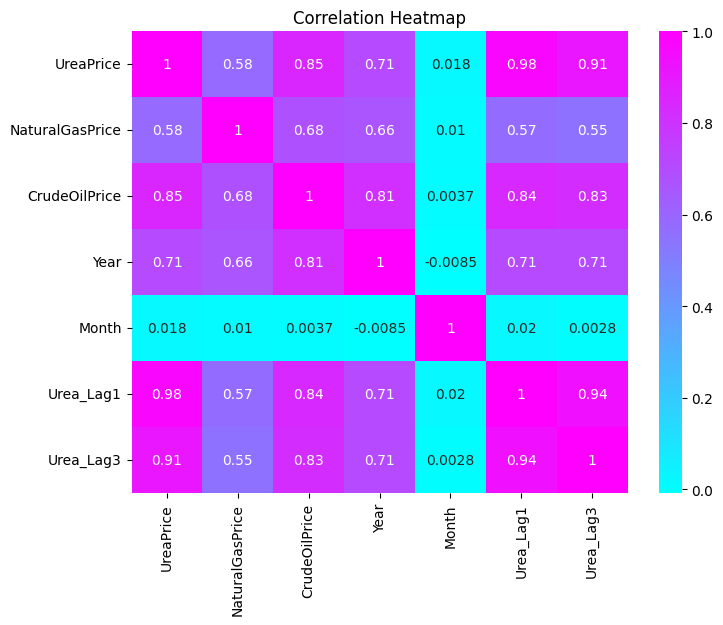

In [ ]:
#eda process start
#correlational matrix

corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='cool')
plt.title("Correlation Heatmap")
plt.show()

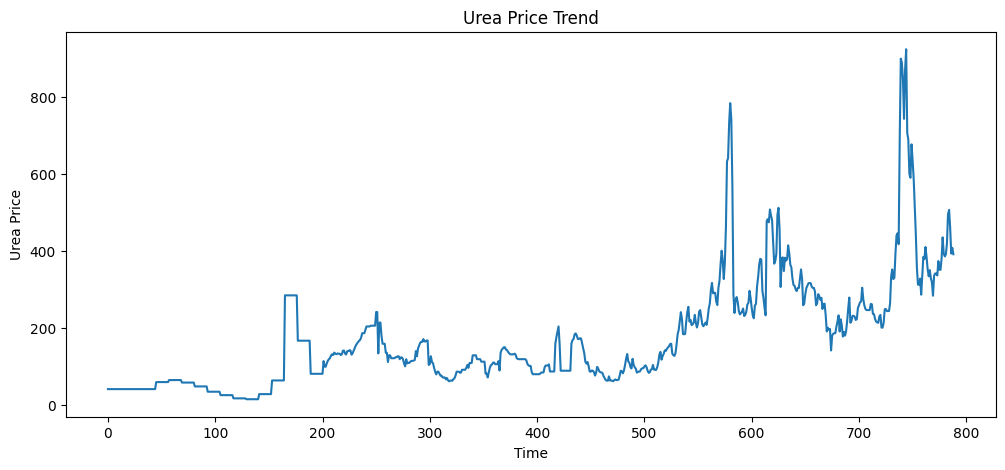

In [ ]:
#uera price trend recognition

plt.figure(figsize=(12,5))
plt.plot(df['UreaPrice'])
plt.title("Urea Price Trend")
plt.xlabel("Time")
plt.ylabel("Urea Price")

plt.show()

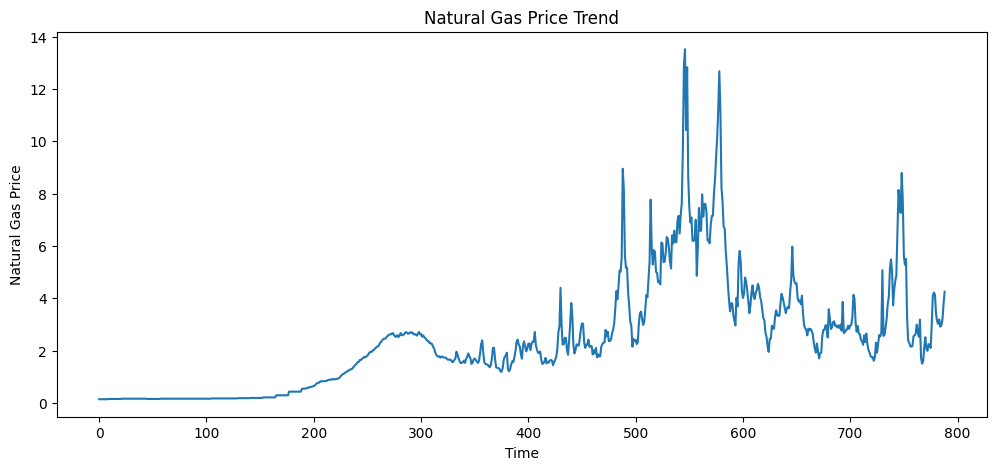

In [ ]:
#natural gas price trend recognition
plt.figure(figsize=(12,5))
plt.plot(df['NaturalGasPrice'])
plt.title("Natural Gas Price Trend")
plt.xlabel("Time")
plt.ylabel("Natural Gas Price")

plt.show()

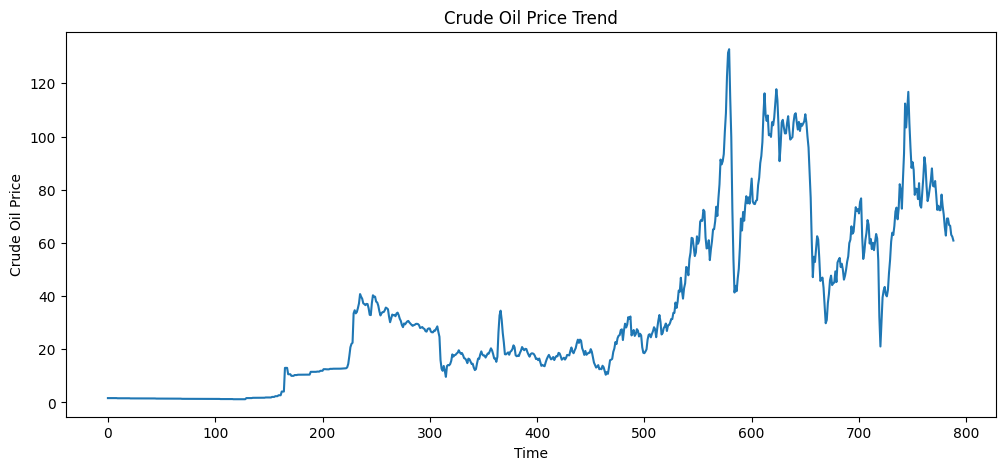

In [ ]:
#crude oil price trend recognition
plt.figure(figsize=(12,5))
plt.plot(df['CrudeOilPrice'])
plt.title("Crude Oil Price Trend")
plt.xlabel("Time")
plt.ylabel("Crude Oil Price")
plt.show()

Text(0, 0.5, 'Frequency')

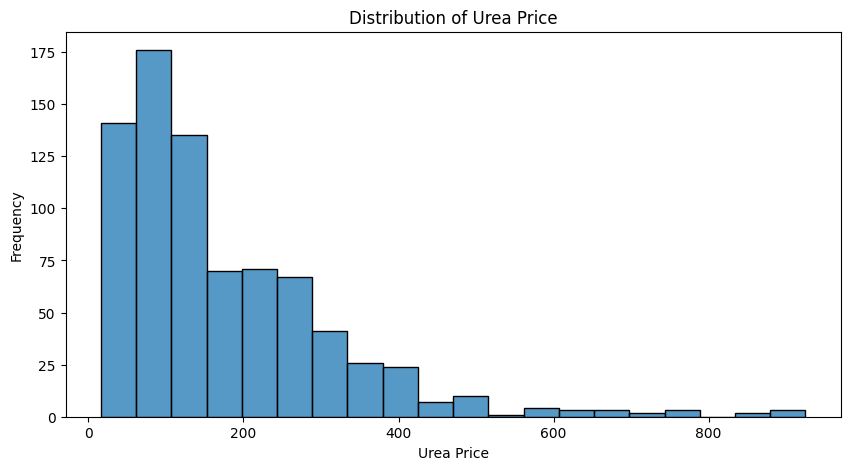

In [ ]:
#distribution of urea price through histogram
plt.figure(figsize=(10,5))
sns.histplot(df['UreaPrice'], bins=20, )
plt.title("Distribution of Urea Price")
plt.xlabel("Urea Price")
plt.ylabel("Frequency")

In [ ]:
#feature engineering
X = df.drop("UreaPrice", axis=1)
y = df["UreaPrice"]
print(X.head())
print(y.head())
df.tail()


   NaturalGasPrice  CrudeOilPrice  Year  Month  Urea_Lag1  Urea_Lag3
0             0.14           1.63  1960      4      42.25      42.25
1             0.14           1.63  1960      5      42.25      42.25
2             0.14           1.63  1960      6      42.25      42.25
3             0.14           1.63  1960      7      42.25      42.25
4             0.14           1.63  1960      8      42.25      42.25
0    42.25
1    42.25
2    42.25
3    42.25
4    42.25
Name: UreaPrice, dtype: float64


,UreaPrice,NaturalGasPrice,CrudeOilPrice,Year,Month,Urea_Lag1,Urea_Lag3
784,507.70,2.91,66.72,2025,8,496.00,392.00
785,461.13,2.97,66.46,2025,9,507.70,420.50
786,394.40,3.20,63.04,2025,10,461.13,496.00
787,409.25,3.79,62.34,2025,11,394.40,507.70
788,392.50,4.25,60.88,2025,12,409.25,461.13


In [ ]:
#splitting of dataset for training and testing 80:20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (631, 6)
Testing Shape: (158, 6)


In [ ]:
#ML model training
#Linear regression
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

#model test
print("LINEAR REGRESSION RESULTS")

print("MAE:",mean_absolute_error(y_test, lr_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:",r2_score(y_test, lr_pred))

LINEAR REGRESSION RESULTS
MAE: 17.094523826883716
RMSE: 37.81099988486191
R2 Score: 0.9489935295607981


In [ ]:
#random forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
#model test
print("RANDOM FOREST RESULTS")

print("MAE:",mean_absolute_error(y_test, rf_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",r2_score(y_test, rf_pred))

RANDOM FOREST RESULTS
MAE: 21.07848164556963
RMSE: 50.00026121020441
R2 Score: 0.9108064408450673


In [ ]:
#xgboost test
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
#model test
print("XGBOOST RESULTS")

print("MAE:",mean_absolute_error(y_test, xgb_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 Score:",r2_score(y_test, xgb_pred))

XGBOOST RESULTS
MAE: 22.567568364686608
RMSE: 57.90888663516632
R2 Score: 0.8803591807329263


In [ ]:
# 3 model comparison
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,17.094524,37.811000,0.948994
1,Random Forest,21.078482,50.000261,0.910806
2,XGBoost,22.567568,57.908887,0.880359


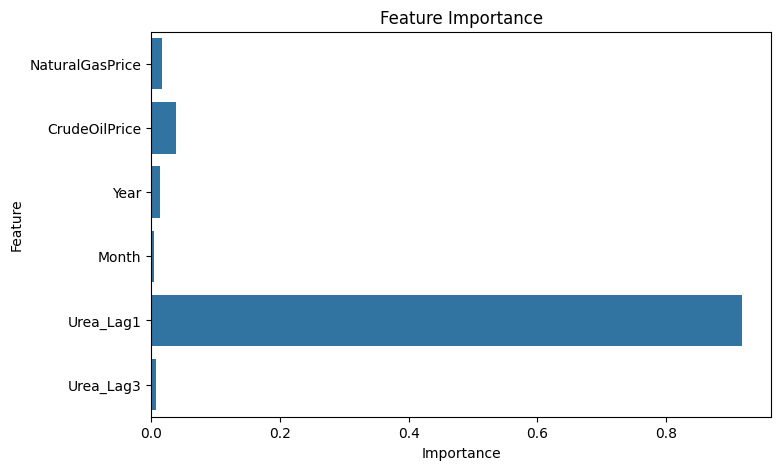

In [ ]:
#feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

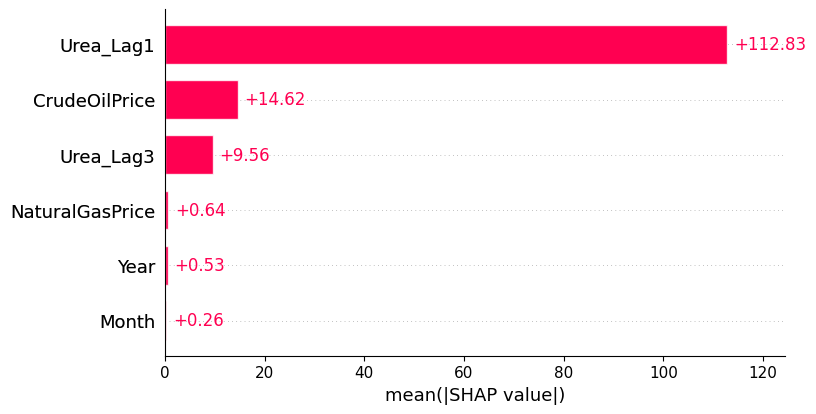

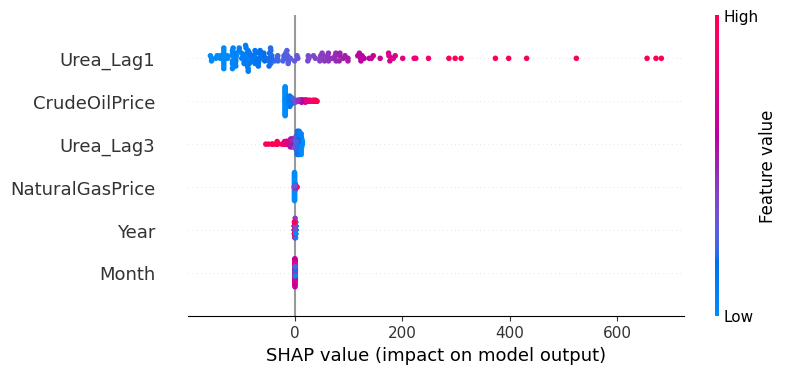

In [ ]:
#shap
import shap
explainer = shap.Explainer(lr, X_train)

shap_values = explainer(X_test)
shap.plots.bar(shap_values)

In [ ]:
#actual prediction
sample = pd.DataFrame({
    'NaturalGasPrice':[3.5],
    'CrudeOilPrice':[80],
    'Year':[2026],
    'Month':[7],
    'Urea_Lag1':[450],
    'Urea_Lag3':[430]
})

prediction = rf.predict(sample)

print("Predicted Urea Price:", prediction[0])

Predicted Urea Price: 402.97399999999993


In [ ]:
import joblib

joblib.dump(lr, 'urea_price_model1.pkl')

print("Model Saved Successfully")


Model Saved Successfully


In [ ]:
from google.colab import files

files.download('urea_price_model1.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
type(lr)

sklearn.linear_model._base.LinearRegression